# Inflation Forecasting with FRED-MD Data

Forecasts **1-month-ahead annualized PCE inflation (PCEPI)** using FRED-MD monthly vintages.

## Cell 1 — Setup, Imports & Helper Functions

In [92]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Resolve data paths (works from notebooks/ or repo root)
VINTAGE_DIR = '../data' if os.path.exists('../data') else 'data'

def setup_plot_style():
    """Set up matplotlib style for consistent plots."""
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (12, 6)
    plt.rcParams['font.size'] = 10

print("Vintage dir :", os.path.abspath(VINTAGE_DIR))
print("Vintage dir exists:", os.path.isdir(VINTAGE_DIR))

Vintage dir : /home/lukeholmes/2025-2026/ML/final-project/Macro-Econ-ML/notebooks/data
Vintage dir exists: True


In [93]:
# Helper functions (data loading + model)
import warnings
import datetime
import requests
from pathlib import Path
from dateutil.relativedelta import relativedelta
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ---------------------------------------------------------------------------
# Transformation helpers
# ---------------------------------------------------------------------------

def _apply_tcode(series, code):
    """Apply a single FRED-MD transformation code to a pandas Series."""
    code = int(code)
    s = series.copy().astype(float)
    if code == 1:
        return s
    elif code == 2:
        return s.diff()
    elif code == 3:
        return s.diff().diff()
    elif code == 4:
        return np.log(s)
    elif code == 5:
        return np.log(s).diff() * 100
    elif code == 6:
        return np.log(s).diff().diff() * 100
    elif code == 7:
        pct = s / s.shift(1) - 1
        return pct.diff() * 100
    else:
        warnings.warn(f"Unknown tcode {code}, returning series unchanged.")
        return s


def apply_fred_md_transforms(df, tcodes):
    """
    Apply FRED-MD transformation codes to each column.

    Args:
        df: DataFrame with raw series (dates as index)
        tcodes: dict mapping column name -> tcode (int or float)

    Returns:
        Transformed DataFrame (same shape, NaNs introduced at boundaries)
    """
    transformed = {}
    for col in df.columns:
        if col in tcodes:
            transformed[col] = _apply_tcode(df[col], tcodes[col])
        else:
            transformed[col] = df[col].copy()
    return pd.DataFrame(transformed, index=df.index)


# ---------------------------------------------------------------------------
# Data loading functions
# ---------------------------------------------------------------------------

def load_fred_md_file(filepath):
    """
    Load a single FRED-MD CSV file.

    FRED-MD format:
      Row 1: transformation codes (tcode) for each series
      Row 2+: monthly observations

    Returns:
        Tuple (transformed_df, tcodes_dict)
    """
    filepath = str(filepath)
    raw_all = pd.read_csv(filepath, header=None)
    headers = raw_all.iloc[0].tolist()
    tcode_row = raw_all.iloc[1].tolist()

    date_col = headers[0]
    tcodes = {}
    for h, t in zip(headers[1:], tcode_row[1:]):
        try:
            tcodes[str(h)] = float(t)
        except (ValueError, TypeError):
            pass

    df = raw_all.iloc[2:].copy()
    df.columns = headers
    df = df.reset_index(drop=True)

    date_col_actual = df.columns[0]
    df[date_col_actual] = pd.to_datetime(df[date_col_actual])
    df = df.set_index(date_col_actual)
    df.index.name = 'date'
    df = df.dropna(how='all')

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df_transformed = apply_fred_md_transforms(df, tcodes)
    return df_transformed, tcodes


def get_latest_vintage(vintage_dir):
    """
    Find the most recent vintage CSV file in a directory.

    Vintage files are named like '2025-01.csv', '2024-12.csv', etc.

    Returns:
        Path to the most recent vintage file
    """
    vintage_dir = Path(vintage_dir)
    csv_files = list(vintage_dir.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {vintage_dir}")
    csv_files_sorted = sorted(csv_files, key=lambda p: p.stem)
    latest = csv_files_sorted[-1]
    print(f"Using latest vintage: {latest.name}")
    return latest


def _is_valid_fred_md_csv(path):
    """Return True if the file looks like a real FRED-MD CSV (not an HTML error page)."""
    try:
        with open(path, 'r', errors='replace') as f:
            first_line = f.readline()
        lower = first_line.lower()
        return 'sasdate' in lower or (not lower.startswith('<') and ',' in first_line)
    except Exception:
        return False


def download_latest_vintage(data_dir):
    """Try current month then back up until a FRED-MD vintage CSV is found; download it."""
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    base_url = ("https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed"
                "/research/fred-md/monthly/{year:04d}-{month:02d}-md.csv")

    today = datetime.date.today()
    for delta in range(6):   # try up to 6 months back
        candidate = today.replace(day=1) - relativedelta(months=delta)
        year, month = candidate.year, candidate.month
        filename = f"{year:04d}-{month:02d}-MD.csv"
        local_path = data_dir / filename
        if local_path.exists():
            if _is_valid_fred_md_csv(local_path):
                print(f"Already have {filename}")
                return local_path
            else:
                print(f"Removing invalid cached file {filename}")
                local_path.unlink()
        url = base_url.format(year=year, month=month)
        try:
            resp = requests.get(url, timeout=30)
            if resp.status_code == 200:
                # Reject HTML responses (the Fed returns 200 for missing vintages)
                snippet = resp.content[:200].decode('utf-8', errors='replace')
                if '<html' in snippet.lower() or '<!doctype' in snippet.lower():
                    print(f"  {filename}: URL returned HTML — vintage not yet published")
                    continue
                local_path.write_bytes(resp.content)
                print(f"Downloaded {filename}")
                return local_path
        except requests.RequestException:
            pass
    raise RuntimeError("Could not download any recent FRED-MD vintage.")


def build_dataset_from_csv(filepath, horizon=1,
                            test_start='2025-07-01', val_start='2023-01-01'):
    """
    Build train/val/test datasets from a single FRED-MD vintage CSV.

    Target: PCEPI first-log-diff x100 (monthly % change), shifted by `horizon`.
    Features: all columns transformed by their tcodes (PCEPI included with tcode=6).
    Splits are date-based (no shuffling).
    """
    filepath = str(filepath)
    raw_all = pd.read_csv(filepath, header=None)
    headers = raw_all.iloc[0].tolist()
    tcode_row = raw_all.iloc[1].tolist()

    # Build tcode dict
    tcodes = {}
    for h, t in zip(headers[1:], tcode_row[1:]):
        try:
            tcodes[str(h)] = float(t)
        except (ValueError, TypeError):
            pass

    # Raw data (before tcode transforms)
    df_raw = raw_all.iloc[2:].copy()
    df_raw.columns = headers
    df_raw = df_raw.reset_index(drop=True)
    date_col = df_raw.columns[0]
    df_raw[date_col] = pd.to_datetime(df_raw[date_col])
    df_raw = df_raw.set_index(date_col)
    df_raw.index.name = 'date'
    df_raw = df_raw.dropna(how='all')
    for col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    # Snap month-start dates to month-end for consistent alignment
    df_raw.index = df_raw.index + pd.offsets.MonthEnd(0)

    # --- Build target from raw PCEPI levels ---
    pcepi_raw = df_raw['PCEPI']
    target = np.log(pcepi_raw).diff() * 100   # first log diff x100
    target_shifted = target.shift(-horizon)    # y[t] = inflation at t+horizon

    # --- Build features (tcode-transformed) ---
    df_features = apply_fred_md_transforms(df_raw, tcodes)
    df_features = df_features.ffill().bfill()

    # Combine and drop rows with no target
    df = df_features.copy()
    df['_target'] = target_shifted
    df = df.dropna(subset=['_target'])

    X = df.drop(columns=['_target'])
    y = df['_target']

    # Drop all-NaN feature columns
    X = X.dropna(axis=1, how='all')
    feature_names = X.columns.tolist()

    # Date-based splits
    test_mask  = X.index >= pd.Timestamp(test_start)
    val_mask   = (X.index >= pd.Timestamp(val_start)) & ~test_mask
    train_mask = ~val_mask & ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    print(f"\nDataset summary (PCEPI first-log-diff target, {horizon}-month-ahead):")
    print(f"  Train : {len(X_train):4d} obs  {X_train.index.min().date()} -> {X_train.index.max().date()}")
    print(f"  Val   : {len(X_val):4d} obs  {X_val.index.min().date()} -> {X_val.index.max().date()}")
    print(f"  Test  : {len(X_test):4d} obs  {X_test.index.min().date()} -> {X_test.index.max().date()}")
    print(f"  Features: {len(feature_names)}")

    return X_train, y_train, X_val, y_val, X_test, y_test, feature_names


# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------

class InflationForecaster:
    """ElasticNet forecaster for inflation time series."""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.model = None
        self.scaler = StandardScaler()
        self.best_params = None

    def _get_model(self):
        return ElasticNet(random_state=self.random_state, max_iter=10000)

    def _get_param_grid(self):
        return {
            'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        }

    def train(self, X_train, y_train, tune_hyperparameters=True, cv_folds=5):
        X_train_scaled = self.scaler.fit_transform(X_train)
        if tune_hyperparameters:
            print("Tuning ElasticNet hyperparameters...")
            tscv = TimeSeriesSplit(n_splits=cv_folds)
            grid_search = GridSearchCV(
                self._get_model(),
                self._get_param_grid(),
                cv=tscv,
                scoring='neg_mean_squared_error',
                n_jobs=-1,
                verbose=1,
            )
            grid_search.fit(X_train_scaled, y_train)
            self.model = grid_search.best_estimator_
            self.best_params = grid_search.best_params_
            print(f"Best parameters: {self.best_params}")
            print(f"Best CV score (RMSE): {np.sqrt(-grid_search.best_score_):.4f}")
        else:
            print("Training ElasticNet with default parameters...")
            self.model = self._get_model()
            self.model.fit(X_train_scaled, y_train)
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model must be trained before making predictions")
        return self.model.predict(self.scaler.transform(X))

    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test)
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
            'mae': mean_absolute_error(y_test, y_pred),
            'r2': r2_score(y_test, y_pred),
            'mape': np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100,
        }
        return metrics, y_pred

    def get_feature_importance(self, feature_names):
        if self.model is None:
            raise ValueError("Model must be trained first")
        if hasattr(self.model, 'coef_'):
            importance = np.abs(self.model.coef_)
        elif hasattr(self.model, 'feature_importances_'):
            importance = self.model.feature_importances_
        else:
            return None
        return pd.DataFrame({
            'feature': feature_names,
            'importance': importance,
        }).sort_values('importance', ascending=False)

## Cell 2 — Data Loading

In [94]:
# Download (or locate) most recent FRED-MD vintage
vintage_file = download_latest_vintage(VINTAGE_DIR)

# Build dataset entirely from CSV
X_train, y_train, X_val, y_val, X_test, y_test, feature_names = build_dataset_from_csv(
    filepath=vintage_file,
    horizon=1,
    test_start='2025-07-01',
    val_start='2023-01-01',
)

print(f"\nTrain  samples : {len(X_train)}  features: {len(feature_names)}")
print(f"  Date range   : {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f"\nVal    samples : {len(X_val)}")
print(f"  Date range   : {X_val.index.min().date()} -> {X_val.index.max().date()}")
print(f"\nTest   samples : {len(X_test)}")
if len(X_test):
    print(f"  Date range   : {X_test.index.min().date()} -> {X_test.index.max().date()}")

  2026-03-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-02-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  768 obs  1959-01-31 -> 2022-12-31
  Val   :   30 obs  2023-01-31 -> 2025-06-30
  Test  :    5 obs  2025-07-31 -> 2025-11-30
  Features: 126

Train  samples : 768  features: 126
  Date range   : 1959-01-31 -> 2022-12-31

Val    samples : 30
  Date range   : 2023-01-31 -> 2025-06-30

Test   samples : 5
  Date range   : 2025-07-31 -> 2025-11-30


In [95]:
# Load raw (transformed) vintage file to inspect PCEPI growth series
df_train_full, tcodes = load_fred_md_file(vintage_file)

# Show tcodes for key series
key_series = ['PCEPI', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'TB3MS', 'GS10', 'INDPRO', 'HOUST']
tcode_info = {s: tcodes.get(s, 'N/A') for s in key_series if s in tcodes or s in df_train_full.columns}
tcode_df = pd.DataFrame(list(tcode_info.items()), columns=['Series', 'TCode'])
tcode_descriptions = {
    1: 'No transform', 2: '1st diff', 3: '2nd diff',
    4: 'Log', 5: 'Log 1st diff x100', 6: 'Log 1st diff x100', 7: 'Delta pct chg x100'
}
tcode_df['Transform'] = tcode_df['TCode'].map(lambda x: tcode_descriptions.get(int(x), str(x)) if x != 'N/A' else 'N/A')
print("Transformation codes for key series:")
print(tcode_df.to_string(index=False))


print("\nLag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)")
print(f"  Features cover: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"  y[t] covers   : {y_train.index.min().date()} to {y_train.index.max().date()}")

Transformation codes for key series:
  Series  TCode         Transform
   PCEPI    6.0 Log 1st diff x100
CPIAUCSL    6.0 Log 1st diff x100
  UNRATE    2.0          1st diff
FEDFUNDS    2.0          1st diff
   TB3MS    2.0          1st diff
    GS10    2.0          1st diff
  INDPRO    5.0 Log 1st diff x100
   HOUST    4.0               Log

Lag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)
  Features cover: 1959-01-31 to 2022-12-31
  y[t] covers   : 1959-01-31 to 2022-12-31


## Cell 4 — Exploratory Data Analysis

<Figure size 1400x500 with 0 Axes>

Top 15 features correlated with 1-month-ahead PCEPI growth:
TB3SMFFM         0.472
TB6SMFFM         0.445
AAAFFM           0.430
ACOGNO           0.417
COMPAPFFx        0.399
T10YFFM          0.396
BUSINVx          0.392
BAAFFM           0.382
T5YFFM           0.380
M2REAL           0.337
T1YFFM           0.334
AWHMAN           0.328
CES0600000007    0.311
AMDMUOx          0.237
HOUST            0.204


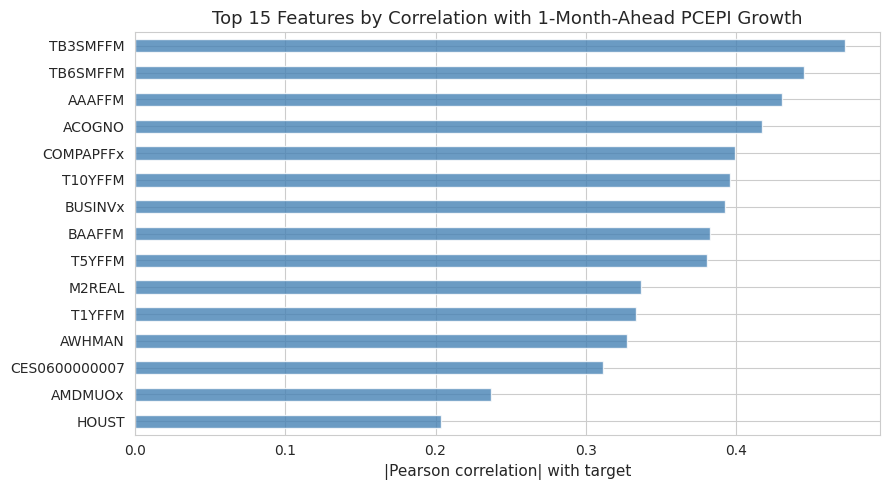

In [96]:
plt.figure(figsize=(14, 5))

# --- PCEPI 1-month-ahead target over time ---
axes[1].plot(y_train.index, y_train.values, linewidth=1.2, color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_title('1-Month-Ahead PCEPI Growth (train target)')
axes[1].set_ylabel('Monthly % Growth (log diff × 100)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

# --- Top 15 features correlated with target ---
corr = X_train.corrwith(y_train).abs().dropna().sort_values(ascending=False)
print("Top 15 features correlated with 1-month-ahead PCEPI growth:")
print(corr.head(15).round(3).to_string())

top_corr = corr.head(15)
if len(top_corr) > 0:
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    top_corr.plot(kind='barh', ax=ax2, color='steelblue', alpha=0.8)
    ax2.set_xlabel('|Pearson correlation| with target')
    ax2.set_title('Top 15 Features by Correlation with 1-Month-Ahead PCEPI Growth')
    ax2.invert_yaxis()
    fig2.tight_layout()
    plt.show()
else:
    print("No valid correlations computed (all NaN).")

## Cell 5 — Train ElasticNet

Tuning ElasticNet hyperparameters...
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best parameters: {'alpha': 0.01, 'l1_ratio': 0.5}
Best CV score (RMSE): 0.2313
TimeSeriesSplit CV results (ElasticNet, best params):
 fold  n_val     rmse      mae        r2
    1     69 0.221366 0.167740 -2.253900
    2     69 0.398353 0.304475 -1.247717
    3     69 0.201885 0.166593  0.134014
    4     69 0.257546 0.213914 -1.677468
    5     69 0.229975 0.201854 -1.186637
    6     69 0.156675 0.126292 -1.037764
    7     69 0.183788 0.137258  0.036953
    8     69 0.265939 0.193850  0.112864
    9     69 0.141051 0.111162  0.082239
   10     69 0.265889 0.190428 -0.244750

Mean CV RMSE: 0.2322  |  Mean R²: -0.7282
Best hyperparams: {'alpha': 0.01, 'l1_ratio': 0.5}


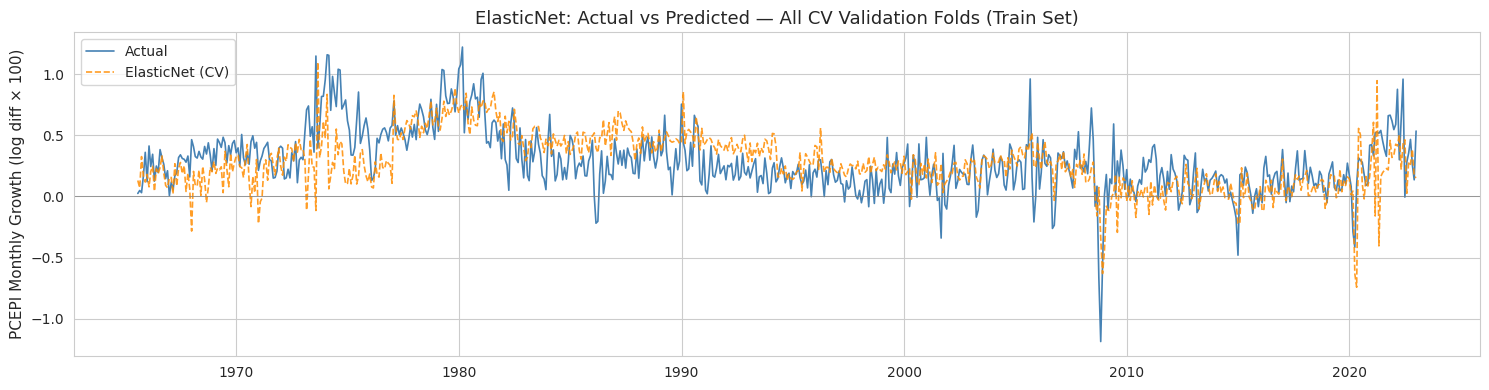

In [97]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

CV_FOLDS = 10   # single place to adjust

# --- Train ElasticNet with TimeSeriesSplit CV ---
elasticnet = InflationForecaster(random_state=42)
elasticnet.train(X_train, y_train, tune_hyperparameters=True, cv_folds=CV_FOLDS)

# --- Cross-validation fold performance ---
tscv = TimeSeriesSplit(n_splits=CV_FOLDS)
fold_metrics = []
all_val_dates = []
all_val_actual = []
all_val_pred = []

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

best_alpha    = elasticnet.best_params.get('alpha', 0.1)
best_l1_ratio = elasticnet.best_params.get('l1_ratio', 0.5)
X_arr = X_train.values
y_arr = y_train.values

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_arr)):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_arr[tr_idx])
    Xval = scaler.transform(X_arr[val_idx])
    ytr, yval = y_arr[tr_idx], y_arr[val_idx]

    m = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000, random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xval)

    fold_metrics.append({
        'fold': fold + 1,
        'n_val': len(yval),
        'rmse': np.sqrt(mean_squared_error(yval, pred)),
        'mae':  mean_absolute_error(yval, pred),
        'r2':   r2_score(yval, pred),
    })

    # Accumulate predictions across all folds for plotting
    all_val_dates.extend(X_train.index[val_idx])
    all_val_actual.extend(yval)
    all_val_pred.extend(pred)

cv_df = pd.DataFrame(fold_metrics)
print("TimeSeriesSplit CV results (ElasticNet, best params):")
print(cv_df.to_string(index=False))
print(f"\nMean CV RMSE: {cv_df['rmse'].mean():.4f}  |  Mean R²: {cv_df['r2'].mean():.4f}")
print(f"Best hyperparams: {elasticnet.best_params}")

# --- Plot predictions across all CV folds ---
all_val_dates  = pd.DatetimeIndex(all_val_dates)
all_val_actual = np.array(all_val_actual)
all_val_pred   = np.array(all_val_pred)

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(all_val_dates, all_val_actual, '-', label='Actual', linewidth=1.2, color='steelblue')
ax.plot(all_val_dates, all_val_pred,   '--', label='ElasticNet (CV)', linewidth=1.2, alpha=0.85, color='darkorange')
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('ElasticNet: Actual vs Predicted — All CV Validation Folds (Train Set)')
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()


Out-of-Sample Test Performance (ElasticNet, held-out 15%):
  Test date range: 2025-07-31 to 2025-11-30
  n observations : 5
  RMSE : 0.1064
  MAE  : 0.0880
  R²   : -2.7258
  MAPE : 35.33%

  LATEST FORECAST
  Forecast date : January 2026  (1/1/2026)
  Using features: December 2025
  Predicted PCEPI Monthly Growth: +0.2657%  (log diff × 100)
  Annualized (approx.)          : +3.19%


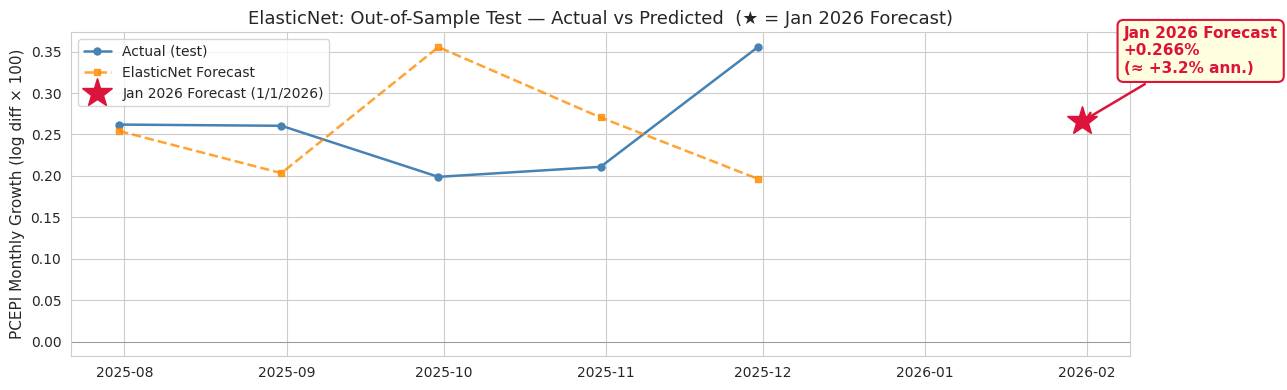

In [98]:
if len(X_test) == 0:
    print("WARNING: No out-of-sample test observations available.")
else:
    # Align test features to training feature set
    test_cols = [c for c in feature_names if c in X_test.columns]
    X_test_aligned = X_test[test_cols]

    test_metrics, y_test_pred = elasticnet.evaluate(X_test_aligned, y_test)

    print(f"Out-of-Sample Test Performance (ElasticNet, held-out 15%):")
    print(f"  Test date range: {X_test.index.min().date()} to {X_test.index.max().date()}")
    print(f"  n observations : {len(X_test)}")
    print(f"  RMSE : {test_metrics['rmse']:.4f}")
    print(f"  MAE  : {test_metrics['mae']:.4f}")
    print(f"  R²   : {test_metrics['r2']:.4f}")
    print(f"  MAPE : {test_metrics['mape']:.2f}%")

# ---------------------------------------------------------------------------
# Build Jan 2026 forecast using Dec 2025 features
# (Dec 2025 is dropped from X_test because Jan 2026 actual is not yet published)
# ---------------------------------------------------------------------------
import warnings

raw_all = pd.read_csv(str(vintage_file), header=None)
headers_raw = raw_all.iloc[0].tolist()
tcode_row_raw = raw_all.iloc[1].tolist()
tcodes_raw = {}
for h, t in zip(headers_raw[1:], tcode_row_raw[1:]):
    try:
        tcodes_raw[str(h)] = float(t)
    except (ValueError, TypeError):
        pass
df_raw2 = raw_all.iloc[2:].copy()
df_raw2.columns = headers_raw
df_raw2 = df_raw2.reset_index(drop=True)
dc = df_raw2.columns[0]
df_raw2[dc] = pd.to_datetime(df_raw2[dc])
df_raw2 = df_raw2.set_index(dc)
df_raw2.index.name = 'date'
df_raw2 = df_raw2.dropna(how='all')
for col in df_raw2.columns:
    df_raw2[col] = pd.to_numeric(df_raw2[col], errors='coerce')
df_raw2.index = df_raw2.index + pd.offsets.MonthEnd(0)

df_feat2 = apply_fred_md_transforms(df_raw2, tcodes_raw).ffill().bfill()

dec_2025_row = df_feat2.loc[df_feat2.index == pd.Timestamp('2025-12-31')]
forecast_cols = [c for c in feature_names if c in dec_2025_row.columns]
X_jan2026 = dec_2025_row[forecast_cols]
jan_2026_forecast = elasticnet.predict(X_jan2026)[0]

print(f"\n{'='*55}")
print(f"  LATEST FORECAST")
print(f"  Forecast date : January 2026  (1/1/2026)")
print(f"  Using features: December 2025")
print(f"  Predicted PCEPI Monthly Growth: {jan_2026_forecast:+.4f}%  (log diff × 100)")
print(f"  Annualized (approx.)          : {jan_2026_forecast * 12:+.2f}%")
print(f"{'='*55}")

# ---------------------------------------------------------------------------
# Plot: test actuals + Jan 2026 forecast
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))

if len(X_test) > 0:
    ax.plot(y_test.index, y_test.values, 'o-', label='Actual (test)', linewidth=1.8,
            markersize=5, color='steelblue')
    ax.plot(y_test.index, y_test_pred, 's--', label='ElasticNet Forecast', linewidth=1.8,
            alpha=0.8, markersize=5, color='darkorange')

# Jan 2026 forecast point — large prominent star
jan_ts = pd.Timestamp('2026-01-31')
ax.plot(jan_ts, jan_2026_forecast, '*', color='crimson', markersize=22,
        label='Jan 2026 Forecast (1/1/2026)', zorder=5)
ax.annotate(
    f"Jan 2026 Forecast\n{jan_2026_forecast:+.3f}%\n(≈ {jan_2026_forecast*12:+.1f}% ann.)",
    xy=(jan_ts, jan_2026_forecast),
    xytext=(30, 35), textcoords='offset points',
    fontsize=11, fontweight='bold', color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8),
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='crimson', lw=1.5),
)

ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('ElasticNet: Out-of-Sample Test — Actual vs Predicted  (★ = Jan 2026 Forecast)')
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.tight_layout()
plt.show()


## Cell 8 — Feature Importance

Top 15 features by |ElasticNet coefficient|:
      feature  importance
       AWHMAN    0.069817
      BUSINVx    0.065068
     ISRATIOx    0.044109
TWEXAFEGSMTHx    0.033117
       M2REAL    0.033117
      EXSZUSx    0.027409
    COMPAPFFx    0.025565
         GS10    0.024585
      AMDMUOx    0.024220
       ACOGNO    0.023534
      ANDENOx    0.022072
       T5YFFM    0.018683
       UNRATE    0.018388
    CMRMTSPLx    0.016035
       AAAFFM    0.015228

Non-zero coefficients: 49 / 126
(ElasticNet sparsity: L1 penalty drives many to exactly zero)


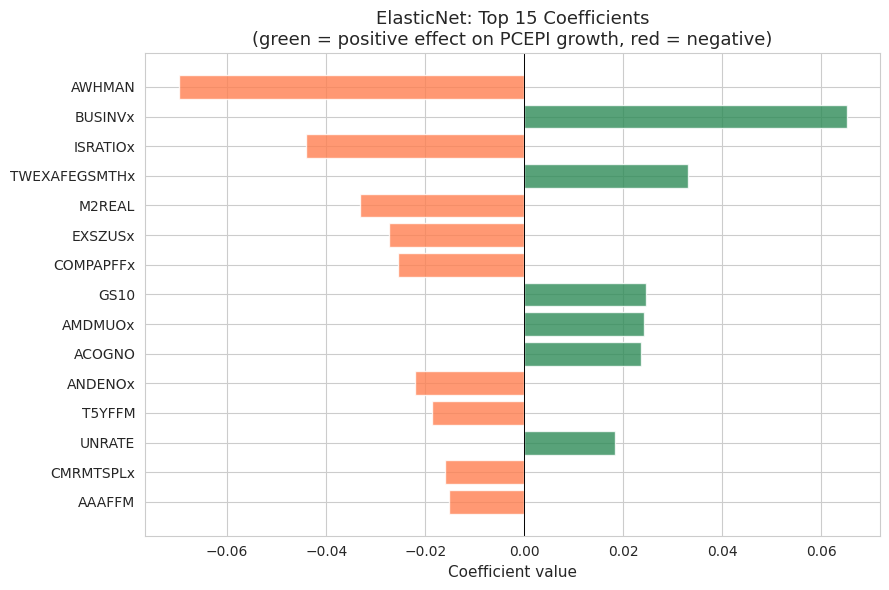

In [99]:
importance_df = elasticnet.get_feature_importance(feature_names)

if importance_df is not None:
    top15 = importance_df.head(15)
    print("Top 15 features by |ElasticNet coefficient|:")
    print(top15.to_string(index=False))

    # Also show signed coefficients for direction
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': elasticnet.model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)

    non_zero = (coef_df['coefficient'] != 0).sum()
    print(f"\nNon-zero coefficients: {non_zero} / {len(feature_names)}")
    print("(ElasticNet sparsity: L1 penalty drives many to exactly zero)")

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['steelblue' if c >= 0 else 'coral' for c in top15['importance'].values]
    # Use signed coef for the top-15 selected by |coef|
    signed_top15 = coef_df.head(15)
    bar_colors = ['seagreen' if c >= 0 else 'coral' for c in signed_top15['coefficient']]
    ax.barh(signed_top15['feature'], signed_top15['coefficient'], color=bar_colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlabel('Coefficient value')
    ax.set_title('ElasticNet: Top 15 Coefficients\n(green = positive effect on PCEPI growth, red = negative)')
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()